 # YouBike 資料清理

 以下是 YouBike2.0 臺北市公共自行車即時資訊資料集中每個欄位的說明，結合頁面上的官方回覆整理而成：



 ---



 **站點識別**



 - **sno**：站點編號（Station Number），每個 YouBike 站點的唯一識別碼，例如 `500101001`。

 - **sna**：站點名稱（中文），例如 `YouBike2.0_捷運科技大樓站`。

 - **snaen**：站點名稱（英文），例如 `YouBike2.0_MRT Technology Bldg. Sta.`。



 **地區資訊**



 - **sarea**：站點所在行政區（中文），例如 `大安區`。

 - **sareaen**：站點所在行政區（英文），例如 `Daan Dist.`。

 - **ar**：站點地址（中文），例如 `復興南路二段235號前`。

 - **aren**：站點地址（英文），例如 `No.235, Sec. 2, Fuxing S. Rd.`。



 **地理座標**



 - **latitude**：站點緯度（decimal degrees）。

 - **longitude**：站點經度（decimal degrees）。



 **車輛與停車格數量**



 - **Quantity**：站點總停車格數（即 tot，場站總停車格）。

 - **available_rent_bikes**：目前可借車輛數（即 sbi，場站目前可用車輛數量）。

 - **available_return_bikes**：目前可還空位數（即 bemp，空位數量）。



 **時間資訊**（根據官方回覆）



 - **mday**：微笑單車各場站的來源資料更新時間。

 - **srcUpdateTime**：微笑單車系統發布資料更新的時間。

 - **updateTime**：臺北市政府交通局數據平台處理後，將資料存入資料庫（DB）的時間。

 - **infoTime**：微笑單車各場站來源資料更新時間。

 - **infoDate**：微笑單車各場站來源資料更新日期。



 **狀態**



 - **act**：全站啟用狀態，`0` 表示禁用、`1` 表示啟用。



 ---



 簡單來說，這份資料每分鐘更新一次，讓使用者可以即時查詢每個 YouBike 站點的位置、可借/可還數量，以及站點目前是否正常運作。

In [1]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
import pandas as pd

data = pd.read_csv('youbike_data.csv')

data.head()

,sno,sna,sarea,mday,ar,sareaen,snaen,aren,act,srcUpdateTime,updateTime,infoTime,infoDate,Quantity,available_rent_bikes,latitude,longitude,available_return_bikes
0,500101001,YouBike2.0_捷運科技大樓站,大安區,2025-12-08 18:50:05,復興南路二段235號前,Daan Dist.,YouBike2.0_MRT Technology Bldg. Sta.,No.235， Sec. 2， Fuxing S. Rd.,1,2025-12-08 18:59:29,2025-12-08 18:59:53,2025-12-08 18:50:05,2025-12-08,28,17,25.02605,121.54360,11
1,500101002,YouBike2.0_復興南路二段273號前,大安區,2025-12-08 18:53:17,復興南路二段273號西側,Daan Dist.,YouBike2.0_No.273， Sec. 2， Fuxing S. Rd.,No.273， Sec. 2， Fuxing S. Rd. (West),1,2025-12-08 18:59:29,2025-12-08 18:59:53,2025-12-08 18:53:17,2025-12-08,21,21,25.02565,121.54357,0
2,500101003,YouBike2.0_國北教大實小東側門,大安區,2025-12-08 18:30:03,和平東路二段96巷7號,Daan Dist.,YouBike2.0_NTUE Experiment Elementary School (...,No. 7， Ln. 96， Sec. 2， Heping E. Rd,1,2025-12-08 18:59:29,2025-12-08 18:59:53,2025-12-08 18:30:03,2025-12-08,28,19,25.02429,121.54124,8
3,500101004,YouBike2.0_和平公園東側,大安區,2025-12-08 18:32:15,和平東路二段118巷33號,Daan Dist.,YouBike2.0_Heping Park (East),No. 33， Ln. 118， Sec. 2， Heping E. Rd,1,2025-12-08 18:59:29,2025-12-08 18:59:53,2025-12-08 18:32:15,2025-12-08,11,8,25.02351,121.54282,2
4,500101005,YouBike2.0_辛亥復興路口西北側,大安區,2025-12-08 18:50:05,復興南路二段368號,Daan Dist.,YouBike2.0_Xinhai Fuxing Rd. Intersection (Nor...,No. 368， Sec. 2， Fuxing S. Rd.,1,2025-12-08 18:59:29,2025-12-08 18:59:53,2025-12-08 18:50:05,2025-12-08,16,3,25.02153,121.54299,13


 ## 步驟三：檢查資料結構與缺失值

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1708 entries, 0 to 1707
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sno                     1708 non-null   int64  
 1   sna                     1708 non-null   str    
 2   sarea                   1708 non-null   str    
 3   mday                    1708 non-null   str    
 4   ar                      1708 non-null   str    
 5   sareaen                 1708 non-null   str    
 6   snaen                   1708 non-null   str    
 7   aren                    1708 non-null   str    
 8   act                     1708 non-null   int64  
 9   srcUpdateTime           1708 non-null   str    
 10  updateTime              1708 non-null   str    
 11  infoTime                1708 non-null   str    
 12  infoDate                1708 non-null   str    
 13  Quantity                1708 non-null   int64  
 14  available_rent_bikes    1708 non-null   int64  
 15

In [4]:
missing_values = data.isnull().sum()
print("\n各欄位缺失值數量：")

missing_values


各欄位缺失值數量：


sno                       0
sna                       0
sarea                     0
mday                      0
ar                        0
sareaen                   0
snaen                     0
aren                      0
act                       0
srcUpdateTime             0
updateTime                0
infoTime                  0
infoDate                  0
Quantity                  0
available_rent_bikes      0
latitude                  0
longitude                 0
available_return_bikes    0
dtype: int64

 ## 步驟四：格式處理



 將日期時間欄位轉換為 datetime 格式，方便後續時間序列分析。

In [5]:
time_cols = ['mday', 'srcUpdateTime', 'updateTime', 'infoTime']
for col in time_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

print("轉換後各時間欄位型別：")

data[time_cols].dtypes


轉換後各時間欄位型別：


mday             datetime64[us]
srcUpdateTime    datetime64[us]
updateTime       datetime64[us]
infoTime         datetime64[us]
dtype: object

 ## 步驟五：填補缺失值



 使用平均數填補所有數值型欄位的缺失值。

In [6]:
numeric_cols = data.select_dtypes(include='number').columns
for col in numeric_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mean())
        print(f"已填補欄位：{col}")

print("\n填補後各欄位缺失值數量：")

data.isnull().sum()



填補後各欄位缺失值數量：


sno                       0
sna                       0
sarea                     0
mday                      0
ar                        0
sareaen                   0
snaen                     0
aren                      0
act                       0
srcUpdateTime             0
updateTime                0
infoTime                  0
infoDate                  0
Quantity                  0
available_rent_bikes      0
latitude                  0
longitude                 0
available_return_bikes    0
dtype: int64

 ## 步驟六：檢查與刪除重複資料

In [7]:
duplicates = data.duplicated().sum()
print(f"重複資料數量：{duplicates}")

data.drop_duplicates(inplace=True)
print(f"刪除後重複資料數量：{data.duplicated().sum()}")
print(f"剩餘資料筆數：{len(data)}")


重複資料數量：0
刪除後重複資料數量：0
剩餘資料筆數：1708


 ## 步驟七：異常值檢測（箱型圖）



 使用 Seaborn 繪製 `available_rent_bikes`（可借車輛數）的箱型圖，觀察是否有異常值。

<module 'matplotlib.pyplot' from '/Volumes/Dev/nkust/nkust-homework/semester-8/bigdata/260312-demo/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

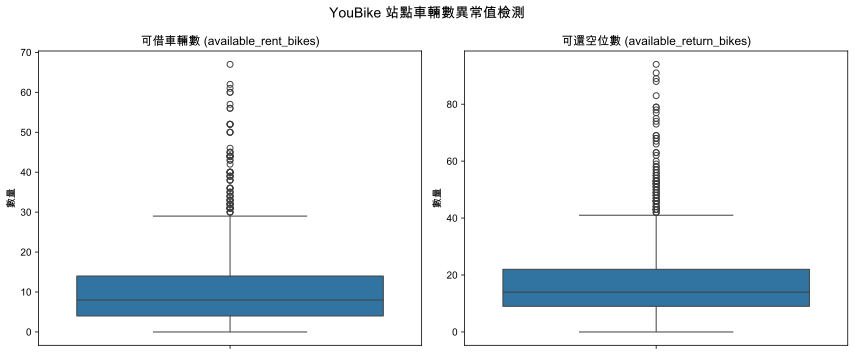

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'sans-serif']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=data['available_rent_bikes'], ax=axes[0])
axes[0].set_title('可借車輛數 (available_rent_bikes)')
axes[0].set_ylabel('數量')

sns.boxplot(y=data['available_return_bikes'], ax=axes[1])
axes[1].set_title('可還空位數 (available_return_bikes)')
axes[1].set_ylabel('數量')

plt.suptitle('YouBike 站點車輛數異常值檢測', fontsize=14)
plt.tight_layout()
plt


## 資料清理總結

In [9]:
print("=== 資料清理完成 ===")
print(f"最終資料筆數：{len(data)}")
print(f"欄位數量：{len(data.columns)}")
print("\n各數值欄位統計摘要：")

data[['Quantity', 'available_rent_bikes', 'available_return_bikes']].describe()


=== 資料清理完成 ===
最終資料筆數：1708
欄位數量：18

各數值欄位統計摘要：


,Quantity,available_rent_bikes,available_return_bikes
count,1708.000000,1708.000000,1708.000000
mean,27.875878,10.338993,16.872365
std,15.084757,9.542331,13.156045
min,5.000000,0.000000,0.000000
25%,18.000000,4.000000,9.000000
50%,24.000000,8.000000,14.000000
75%,33.000000,14.000000,22.000000
max,99.000000,67.000000,94.000000
